In [74]:
import cv2
from matplotlib import pyplot as plt
import numpy as np

(-0.5, 2399.5, 1799.5, -0.5)

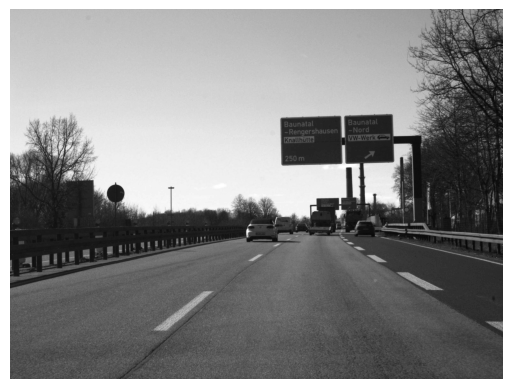

In [96]:

img_streetlines = cv2.imread('real_test.jpg', cv2.COLOR_BGR2RGB)
img = cv2.cvtColor(img_streetlines, cv2.COLOR_BGR2GRAY)

plt.imshow(img, cmap='gray')
plt.axis('off')

testing different approach (not used in following code)

(-0.5, 2399.5, 1799.5, -0.5)

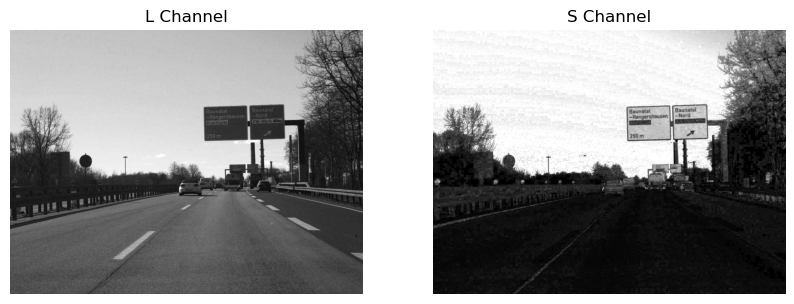

In [87]:
hls = cv2.cvtColor(img_streetlines, cv2.COLOR_BGR2HLS)
l_channel = hls[:, :, 1]
s_channel = hls[:, :, 2]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(l_channel, cmap='gray')
plt.title('L Channel')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(s_channel, cmap='gray')
plt.title('S Channel')
plt.axis('off')

binary img

(-0.5, 2399.5, 1799.5, -0.5)

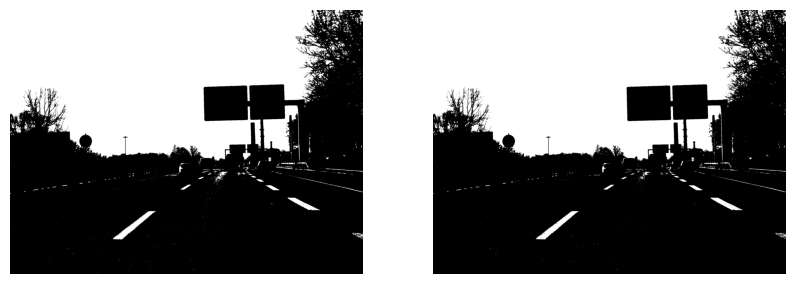

In [100]:
white_pixels = cv2.inRange(img, 130, 255)
lower_bound = cv2.inRange(img, 0, 130)
binary = (img >= 128).astype(int)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(binary, cmap='gray')
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(white_pixels, cmap='gray')
plt.axis('off')

(-0.5, 2399.5, 1799.5, -0.5)

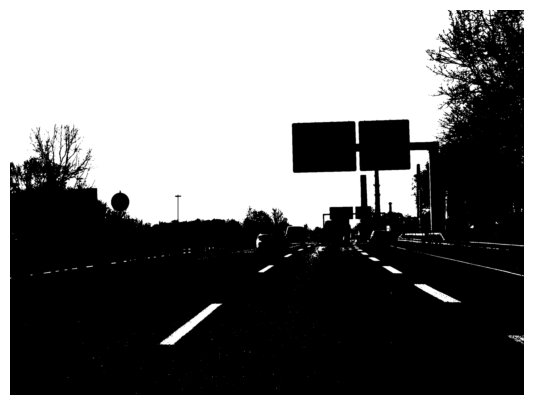

In [103]:
#gaussion filter
kernel_size = 5
blur_gray = cv2.GaussianBlur(white_pixels, (kernel_size, kernel_size), 0)

plt.figure(figsize=(10, 5))
plt.imshow(blur_gray, cmap='gray')
plt.axis('off')

(-0.5, 2399.5, 1799.5, -0.5)

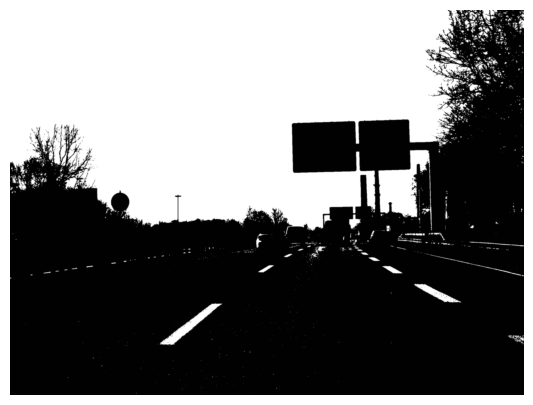

In [104]:
clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
gray = clahe.apply(blur_gray)

plt.figure(figsize=(10, 5))
plt.imshow(gray, cmap='gray')
plt.axis('off')

(-0.5, 2399.5, 1799.5, -0.5)

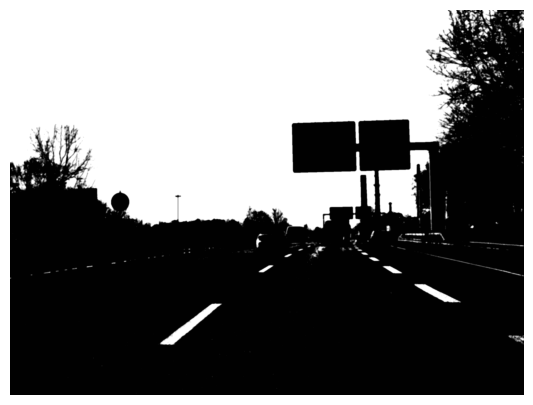

In [105]:
testing = cv2.medianBlur(gray, 7)

plt.figure(figsize=(10, 5))
plt.imshow(testing, cmap='gray')
plt.axis('off')

(-0.5, 2399.5, 1799.5, -0.5)

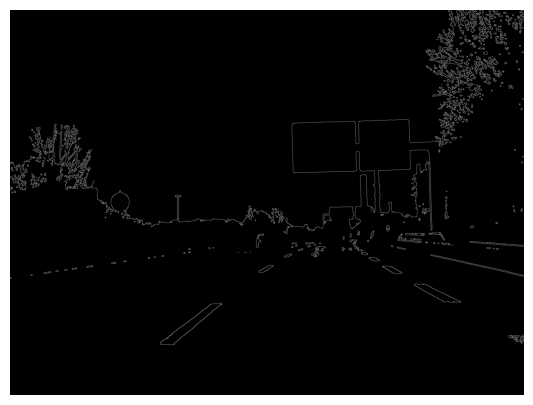

In [106]:
low_threshold = 250
high_threshold = 150
edges = cv2.Canny(testing, low_threshold, high_threshold)

plt.figure(figsize=(10, 5))
plt.imshow(edges, cmap='gray')
plt.axis('off')

(-0.5, 2399.5, 1799.5, -0.5)

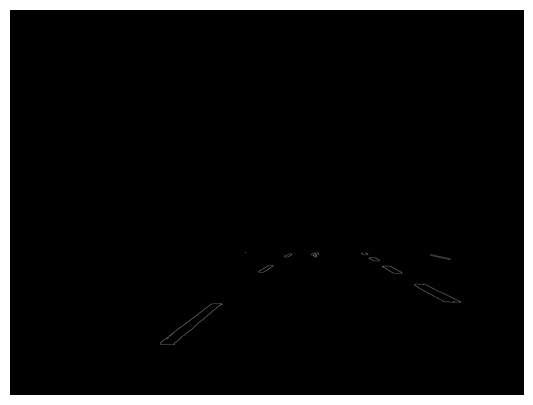

In [107]:
mask = np.zeros_like(edges)
ignore_mask_color = 255

imshape = edges.shape
vertices = np.array([[(0, imshape[0]), \
                      (int(imshape[1] * 0.4), imshape[0]* 0.63), \
                      (int(imshape[1] * 0.85), imshape[0] * 0.63	), \
                      (imshape[1], imshape[0])]], dtype=np.int32)

cv2.fillPoly(mask, vertices, ignore_mask_color)
n_masked_edges = cv2.bitwise_and(edges, mask)

plt.figure(figsize=(10, 5))
plt.imshow(n_masked_edges, cmap='gray')
plt.axis('off')

(-0.5, 2399.5, 1799.5, -0.5)

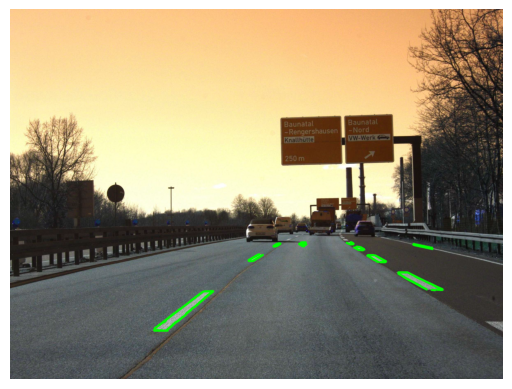

In [ ]:
rho = 2 
theta = np.pi/180 
threshold = 20
min_line_length = 10
max_line_gap = 10 
lines = cv2.HoughLinesP(
    n_masked_edges, rho, theta, threshold, 
    np.array([]), min_line_length, max_line_gap
)

img_with_lines_l = np.copy(img_streetlines)
#plt.imshow(lines, cmap='gray')
#if lines is not None:
    #for line in lines:
        #for x1, y1, x2, y2 in line:
            #angle = np.arctan2(y2 - y1, x2 - x1) * 180 / np.pi
            #if 20 < abs(angle) < 160:  # Filter schließt fast horizontale Linien aus
                #cv2.line(img_with_lines, (x1, y1), (x2, y2), (0, 255, 0), 2)

for line in lines:
   x1, y1, x2, y2 = line[0]
   cv2.line(img_with_lines_l, (x1, y1), (x2, y2), (0, 255, 0), 10)  

plt.imshow(img_with_lines_l, cmap='gray')
plt.axis('off')

In [109]:
# Iterate over the output "lines" to calculate m's and b's 
mxb = np.array([[0,0]])
for line in lines:
    for x1,y1,x2,y2 in line:
        m = (y2-y1) / (x2-x1)
        b = y1 + -1 * m * x1   
        mxb = np.vstack((mxb, [m, b]))

In [110]:
median_right_m = np.median(mxb[mxb[:,0] > 0,0])
median_left_m = np.median(mxb[mxb[:,0] < 0,0])
median_right_b = np.median(mxb[mxb[:,0] > 0,1])
median_left_b = np.median(mxb[mxb[:,0] < 0,1])

In [111]:
# Calculate the Intersect point of our two lines
x_intersect = (median_left_b - median_right_b) / (median_right_m - median_left_m)
y_intersect = median_right_m * (median_left_b - median_right_b) / (median_right_m - median_left_m) + median_right_b
# Calculate the X-Intercept Points
    # x = (y - b) / m
left_bottom = (imshape[0] - median_left_b) / median_left_m
right_bottom = (imshape[0] - median_right_b) / median_right_m

In [112]:
# Create a blank image to draw lines on
line_image = np.copy(img_streetlines) * 0
# Create our Lines
cv2.line(
    line_image,  
    (255,0,0),10
)
cv2.line(
    line_image,
    (0,0,255),10
)
# Draw the lines on the image
lane_edges = cv2.addWeighted(img_streetlines, 0.8, line_image, 1, 0)

plt.figure(figsize=(10, 5))
plt.imshow(lane_edges, cmap='gray')
plt.axis('off')

error: OpenCV(4.11.0) :-1: error: (-5:Bad argument) in function 'line'
> Overload resolution failed:
>  - line() missing required argument 'color' (pos 4)
>  - line() missing required argument 'color' (pos 4)
